In [5]:
import pandas as pd
import numpy as np
import random
import time
import json
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel 
from transformers import logging

In [2]:
batch_size = 64
historical_vector_nums = 50
entities_word_nums = 20
vector_embed_dims = 512
entities_embed_dims = 100
bert_encoding_length = 500
device = 'cuda'

class BertDataset(Dataset):
    def __init__(self, news, tokenizer):
        self.news = news
        self.tokenizer = tokenizer
    
    def __len__(self):
        return len(self.news)
    
    def __getitem__(self, index):
        news_id, category, subcategory, title, abstract, _, _, _ = self.news.iloc[index]
        
        title = "" if isinstance(title, float) else title
        abstract = "" if isinstance(abstract, float) else abstract
        encoding = self.tokenizer(
            text = category + " " + subcategory,
            text_pair = title + " " + abstract,
            return_tensors = "pt",
            padding = "max_length",
            truncation = True,
            max_length = bert_encoding_length
        )
        return news_id, encoding.input_ids[0], encoding.token_type_ids[0], encoding.attention_mask[0]
    
class RecommendationDataset(Dataset):
    def __init__(self, behaviors, news_dict, bert_embedding, entity_embedding, mode='train'):
        self.behaviors = behaviors
        self.news_dict = news_dict
        self.bert_embedding = bert_embedding
        self.entity_embedding = entity_embedding
        self.mode = mode
        
    def __len__(self):
        return len(self.behaviors)

    def padding(self, item, size):
        item = torch.stack(item)[:size]
        if item.size(0) < size:
            padding_length = size - item.size(0)
            padding_item = torch.zeros((padding_length, *item.shape[1:]))
            item = torch.cat((item, padding_item), dim=0)
        return item
    
    def extract_entities(self, news):
        _, _, _, _, _, title_entities, abstract_entities = self.news_dict[news]
        
        title_entities = "[]" if isinstance(title_entities, float) else title_entities
        abstract_entities = "[]" if isinstance(abstract_entities, float) else abstract_entities
        
        vector = []
        entities = json.loads(title_entities)
        ids = [entity['WikidataId'] for entity in entities]
        vector += [torch.tensor(self.entity_embedding[id_]) for id_ in ids if id_ in self.entity_embedding]
        entities = json.loads(abstract_entities)
        ids = [entity['WikidataId'] for entity in entities]
        vector += [torch.tensor(self.entity_embedding[id_]) for id_ in ids if id_ in self.entity_embedding]

        if len(vector) == 0:
            vector = torch.zeros((entities_word_nums, entities_embed_dims))
        else:
            vector = self.padding(vector, entities_word_nums)
                
        return vector
    
    def __getitem__(self, index):
        _, _, clicked_news, impressions = self.behaviors.iloc[index]
        
        clicked_news = clicked_news.split()
        history_bert_vectors = [torch.tensor(self.bert_embedding[news]) for news in clicked_news]
        history_bert_vectors = self.padding(history_bert_vectors, historical_vector_nums)
        history_entity_vectors = [self.extract_entities(news) for news in clicked_news]
        history_entity_vectors = self.padding(history_entity_vectors, historical_vector_nums)

        impressions = impressions.split()
        impression_news = [impression.split('-')[0] for impression in impressions]
        recommen_bert_vectors = [torch.tensor(self.bert_embedding[news]) for news in impression_news]
        recommen_bert_vectors = torch.stack(recommen_bert_vectors)
        recommen_entity_vectors = [self.extract_entities(news) for news in impression_news]
        recommen_entity_vectors = torch.stack(recommen_entity_vectors)

        packed = {
            'history_bert_vectors':    history_bert_vectors,
            'history_entity_vectors':   history_entity_vectors,
            'recommen_bert_vectors':    recommen_bert_vectors,
            'recommen_entity_vectors':  recommen_entity_vectors
        }
        
        if self.mode == 'train':
            labels = torch.tensor([int(impression.split('-')[1]) for impression in impressions])
            return packed, labels
        elif self.mode == 'test':
            return packed

class BaseEncoder(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, output_dim)
        )
            
    def forward(self, x):
        return self.encoder(x.flatten(-2, -1))

class NewsVectorEncoder(nn.Module):
    def __init__(self):
        super(NewsVectorEncoder, self).__init__()

        self.bert_encoder = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, vector_embed_dims // 2)
        )
        self.entity_encoder = BaseEncoder(entities_word_nums * entities_embed_dims, vector_embed_dims // 2)
        
    def forward(self, bert_vectors, entity_vectors):
        bert_out = self.bert_encoder(bert_vectors)
        entity_out = self.entity_encoder(entity_vectors)
        
        return torch.cat((bert_out, entity_out), dim=-1)     
        
class RecommendationModel(nn.Module):
    def __init__(self):
        super(RecommendationModel, self).__init__()
        
        self.nve = NewsVectorEncoder()
        self.uve = BaseEncoder(historical_vector_nums * vector_embed_dims, vector_embed_dims)
    
    def forward(self, history_bert_vectors, history_entity_vectors, recommen_bert_vectors, recommen_entity_vectors):
    
        history_lens = history_entity_vectors.shape[1]
        history_news_vectors = []
        for i in range(history_lens):
            news_vector = self.nve(history_bert_vectors[:, i, :], history_entity_vectors[:, i, :, :])
            history_news_vectors.append(news_vector)
        history_news_vectors = torch.stack(history_news_vectors).permute(1, 0, 2) 
        # (Num News, Batch, Embedded Size) -> (Batch, Num News, Embedded Size)

        recommen_lens = recommen_entity_vectors.shape[1]
        recommen_news_vectors = []
        for i in range(recommen_lens):
            news_vector = self.nve(recommen_bert_vectors[:, i, :], recommen_entity_vectors[:, i, :, :])
            recommen_news_vectors.append(news_vector)
        recommen_news_vectors = torch.stack(recommen_news_vectors).permute(1, 0, 2)
        # (Num News, Batch, Embedded Size) -> (Batch, Num News, Embedded Size)
        
        user_vector = self.uve(history_news_vectors)
        attention_score = (recommen_news_vectors @ user_vector.unsqueeze(-1)).squeeze()
        return attention_score

# Training

In [7]:
'''
news = pd.read_csv('train/train_news.tsv', delimiter='\t', header=None)
news.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'URL', 'title_entities', 'abstract_entities']

logging.set_verbosity_error()
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')
bert = bert.to(device)

bert_dataset = BertDataset(news, tokenizer)
bert_loader = DataLoader(bert_dataset, batch_size=batch_size, shuffle=False)

bert_embedding = {}
for ids, input_ids, token_type_ids, attention_mask in tqdm(bert_loader):
    input_ids = input_ids.to(device)
    token_type_ids = token_type_ids.to(device)
    attention_mask = attention_mask.to(device)
    
    with torch.no_grad():
        bert_output = bert(
            input_ids = input_ids,
            token_type_ids = token_type_ids,
            attention_mask = attention_mask
        )
    
    for id_, output in zip(ids, bert_output[1]):
        bert_embedding[id_] = output

with open('train/train_bert_embedding.vec', 'w') as file:
    for key, values in tqdm(bert_embedding.items()):
        values = [round(v.item(), 6) for v in values]
        line = f"{key} {' '.join(map(str, values))}\n"
        file.write(line)
'''


'\nnews = pd.read_csv(\'train/train_news.tsv\', delimiter=\'\t\', header=None)\nnews.columns = [\'news_id\', \'category\', \'subcategory\', \'title\', \'abstract\', \'URL\', \'title_entities\', \'abstract_entities\']\n\nlogging.set_verbosity_error()\ntokenizer = BertTokenizer.from_pretrained(\'bert-base-uncased\')\nbert = BertModel.from_pretrained(\'bert-base-uncased\')\nbert = bert.to(device)\n\nbert_dataset = BertDataset(news, tokenizer)\nbert_loader = DataLoader(bert_dataset, batch_size=batch_size, shuffle=False)\n\nbert_embedding = {}\nfor ids, input_ids, token_type_ids, attention_mask in tqdm(bert_loader):\n    input_ids = input_ids.to(device)\n    token_type_ids = token_type_ids.to(device)\n    attention_mask = attention_mask.to(device)\n    \n    with torch.no_grad():\n        bert_output = bert(\n            input_ids = input_ids,\n            token_type_ids = token_type_ids,\n            attention_mask = attention_mask\n        )\n    \n    for id_, output in zip(ids, bert_out

In [3]:
behaviors = pd.read_csv('train/train_behaviors.tsv', delimiter='\t', index_col=0, header=None)
behaviors.columns = ['user', 'time', 'clicked_news', 'impressions']
behaviors = behaviors.sample(frac=1, random_state=42)
train_behaviors = behaviors[:int(len(behaviors) * 0.9)]
valid_behaviors = behaviors[int(len(behaviors) * 0.9):]

news = pd.read_csv('train/train_news.tsv', delimiter='\t', header=None)
news.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'URL', 'title_entities', 'abstract_entities']
news_dict = {data['news_id']: data.iloc[1:] for _, data in news.iterrows()}

bert_embedding = {}
f = open('train/train_bert_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    bert_embedding[word] = coefs
f.close()

entity_embedding = {}
f = open('train/train_entity_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    entity_embedding[word] = coefs
f.close()

In [ ]:
from torch.optim.lr_scheduler import StepLR

num_epoch = 10
show_freq = 100

train_dataset = RecommendationDataset(train_behaviors, news_dict, bert_embedding, entity_embedding)
valid_dataset = RecommendationDataset(valid_behaviors, news_dict, bert_embedding, entity_embedding)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

model = RecommendationModel()
model = model.to(device)

loss = nn.MultiLabelSoftMarginLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)

best_valid_auc = 0.0
for epoch in range(num_epoch):
    epoch_start_time = time.time()
    train_loss, valid_loss = 0.0, 0.0
    train_count, valid_count = 0.0, 0.0
    train_true, valid_true = [], []
    train_pred, valid_pred = [], []

    model.train()
    for i, (packed, labels) in enumerate(train_loader):
        for key, value in packed.items():
            packed[key] = value.to(device)
        labels = labels.to(device)
            
        outputs = model(**packed)
        
        batch_loss = loss(outputs, labels)
        batch_loss.backward()
        optimizer.step()
        model.zero_grad()
        
        train_loss += batch_loss.item()
        train_count += labels.shape[0] * labels.shape[1]
        train_true += labels.reshape(-1).cpu().detach().numpy().tolist()
        train_pred += torch.sigmoid(outputs.reshape(-1)).cpu().detach().numpy().tolist()
        
        if (i+1) % show_freq == 0 or (i+1) == len(train_loader):
            train_auc = roc_auc_score(train_true, train_pred)
            print('[{:02d}/{:02d} - {:04d}/{:04d}] '.format(epoch+1, num_epoch, i+1, len(train_loader))
                + '{:2.2f} sec '.format(time.time() - epoch_start_time)
                + 'Train AUC: {:3.2f} Loss: {:3.4f} '.format(train_auc, train_loss/train_count*1000)
            )
    scheduler.step()
            
    model.eval()
    for i, (packed, labels) in enumerate(valid_loader):
        for key, value in packed.items():
            packed[key] = value.to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            outputs = model(**packed)
        
        batch_loss = loss(outputs, labels)
        
        valid_loss += batch_loss.item()
        valid_count += labels.shape[0] * labels.shape[1]
        valid_true += labels.reshape(-1).cpu().detach().numpy().tolist()
        valid_pred += torch.sigmoid(outputs.reshape(-1)).cpu().detach().numpy().tolist()
        
        if (i+1) % show_freq == 0 or (i+1) == len(valid_loader):
            valid_auc = roc_auc_score(valid_true, valid_pred)
            print('[{:02d}/{:02d} - {:04d}/{:04d}] '.format(epoch+1, num_epoch, i+1, len(valid_loader))
                + '{:2.2f} sec '.format(time.time() - epoch_start_time)
                + 'Valid AUC: {:3.2f} Loss: {:3.4f} '.format(valid_auc, valid_loss/valid_count*1000)
            )
            
    if best_valid_auc < valid_auc:
        best_valid_auc = valid_auc
        torch.save(model.state_dict(), 'best_weight.pth')
        
print(f"Best Validation AUC: {best_valid_auc}")

# Testing

In [ ]:
'''
news = pd.read_csv('test/test_news.tsv', delimiter='\t', header=None)
news.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'URL', 'title_entities', 'abstract_entities']

logging.set_verbosity_error()
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')
bert = bert.to(device)

bert_dataset = BertDataset(news, tokenizer)
bert_loader = DataLoader(bert_dataset, batch_size=batch_size, shuffle=False)

bert_embedding = {}
for ids, input_ids, token_type_ids, attention_mask in tqdm(bert_loader):
    input_ids = input_ids.to(device)
    token_type_ids = token_type_ids.to(device)
    attention_mask = attention_mask.to(device)
    
    with torch.no_grad():
        bert_output = bert(
            input_ids = input_ids,
            token_type_ids = token_type_ids,
            attention_mask = attention_mask
        )
    
    for id_, output in zip(ids, bert_output[1]):
        bert_embedding[id_] = output

with open('test/test_bert_embedding.vec', 'w') as file:
    for key, values in tqdm(bert_embedding.items()):
        values = [round(v.item(), 6) for v in values]
        line = f"{key} {' '.join(map(str, values))}\n"
        file.write(line)
'''


In [ ]:
test_behaviors = pd.read_csv('test/test_behaviors.tsv', delimiter='\t', index_col=0, header=None)
test_behaviors.columns = ['user', 'time', 'clicked_news', 'impressions']

news = pd.read_csv('test/test_news.tsv', delimiter='\t', header=None)
news.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'URL', 'title_entities', 'abstract_entities']
news_dict = {data['news_id']: data.iloc[1:] for _, data in news.iterrows()}

bert_embedding = {}
f = open('test/test_bert_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    bert_embedding[word] = coefs
f.close()

entity_embedding = {}
f = open('test/test_entity_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    entity_embedding[word] = coefs
f.close()

In [ ]:
test_dataset = RecommendationDataset(test_behaviors, news_dict, bert_embedding, entity_embedding, mode='test')
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = RecommendationModel()
model = model.to(device)
model.load_state_dict(torch.load('best_weight.pth'))
            
predictions = []
for packed in tqdm(test_loader):
    for key, value in packed.items():
        packed[key] = value.to(device)

    with torch.no_grad():
        outputs = model(**packed)

    predictions += torch.sigmoid(outputs).tolist()
    
df = pd.DataFrame({
    'index': [i for i in range(len(predictions))]
})

for i in range(15):
    df[f"p{i+1}"] = [predictions[j][i] for j in range(len(predictions))]
    
df.to_csv('submission.csv', index=False)

In [ ]:
# cheat read

for i in tqdm(range(len(test_behaviors))):
    user, _, clicked_news, _ = test_behaviors.iloc[i]
    all_news = set(clicked_news.split())
    target = behaviors[behaviors.user == user]
    for impressions in target.impressions:
        all_news |= set([text.split('-')[0] for text in impressions.split() if text.split('-')[1] == '1'])
    test_behaviors.iloc[i]['clicked_news'] = " ".join(all_news)

news = pd.concat([
    pd.read_csv('test/test_news.tsv', delimiter='\t', header=None),
    pd.read_csv('train/train_news.tsv', delimiter='\t', header=None)
])
news.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'URL', 'title_entities', 'abstract_entities']
news_dict = {data['news_id']: data.iloc[1:] for _, data in news.iterrows()}

bert_embedding = {}
f = open('test/test_bert_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    bert_embedding[word] = coefs
f.close()
f = open('train/train_bert_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    bert_embedding[word] = coefs
f.close()

entity_embedding = {}
f = open('test/test_entity_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    entity_embedding[word] = coefs
f.close()
f = open('train/train_entity_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    entity_embedding[word] = coefs
f.close()

# Error Analysis

In [4]:
behaviors = pd.read_csv('train/train_behaviors.tsv', delimiter='\t', index_col=0, header=None)
behaviors.columns = ['user', 'time', 'clicked_news', 'impressions']
behaviors = behaviors.sample(frac=1, random_state=42)
train_behaviors = behaviors[:int(len(behaviors) * 0.9)]
valid_behaviors = behaviors[int(len(behaviors) * 0.9):]

news = pd.read_csv('train/train_news.tsv', delimiter='\t', header=None)
news.columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'URL', 'title_entities', 'abstract_entities']
news_dict = {data['news_id']: data.iloc[1:] for _, data in news.iterrows()}

bert_embedding = {}
f = open('train/train_bert_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    bert_embedding[word] = coefs
f.close()

entity_embedding = {}
f = open('train/train_entity_embedding.vec')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    entity_embedding[word] = coefs
f.close()

In [33]:
valid_dataset = RecommendationDataset(valid_behaviors, news_dict, bert_embedding, entity_embedding)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

model = RecommendationModel()
model = model.to(device)
model.load_state_dict(torch.load('best_weight.pth'))

model.eval()
valid_true, valid_pred = [], []
for packed, labels in tqdm(valid_loader):
    for key, value in packed.items():
        packed[key] = value.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(**packed)

    valid_true += labels.cpu().detach().numpy().tolist()
    valid_pred += torch.sigmoid(outputs).cpu().detach().numpy().tolist()
    
valid_true = np.array(valid_true)
valid_pred = np.array(valid_pred)

100%|██████████| 446/446 [01:25<00:00,  5.25it/s]


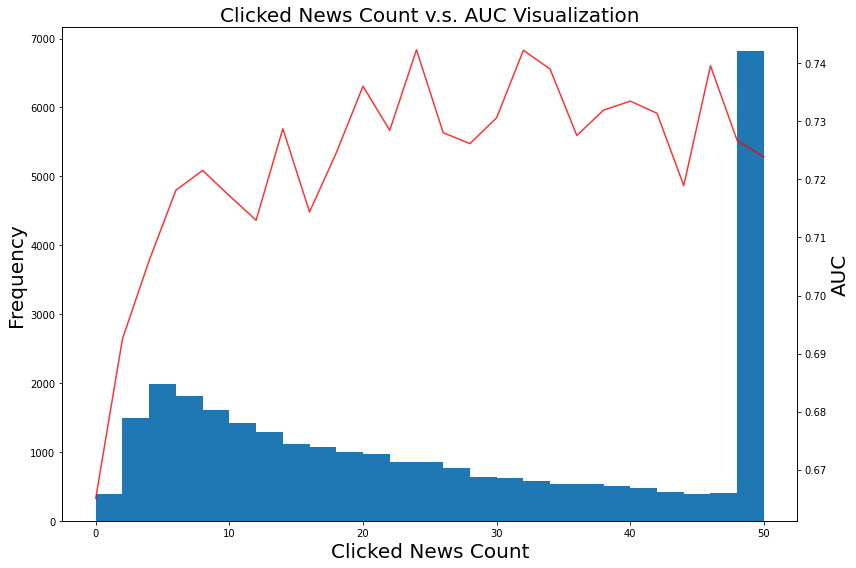

In [105]:
clicked_count = [min(len(clicked_news.split()), 50) for clicked_news in valid_behaviors.clicked_news]
bins = np.arange(0, 51, 2)

auc_scores = []
binned_index = np.digitize(clicked_count, bins) - 1
for i in range(len(bins)):
    indices = (binned_index == i)
    auc_score = roc_auc_score(valid_true[indices].reshape(-1), valid_pred[indices].reshape(-1))
    auc_scores.append(auc_score)

fig, ax1 = plt.subplots(figsize=(12, 8))

# plot histogram on the first y-axis
ax1.set_xlabel('Clicked News Count', fontsize=20)
ax1.set_ylabel('Frequency', fontsize=20)
ax1.hist(clicked_count, bins=bins)
ax1.tick_params(axis='y')
ax1.set_title('Clicked News Count v.s. AUC Visualization', fontsize=20)

# instantiate a second y-axis sharing the same x-axis
ax2 = ax1.twinx()  
ax2.set_ylabel('AUC', fontsize=20)  
ax2.plot(bins, auc_scores, color='red', alpha=0.8)
ax2.tick_params(axis='y')

fig.tight_layout()  
plt.show()